In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [4]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial", "ccnc",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len"
]

# If needed, add TKI ingredients to this list

In [6]:
RUN = ["1"]
#RUN = ["1","2","3_nocrt","3_crt","4b","4c","4d","5"]
#RUN = ["1","2","3","4b","4c","4d","5"] #important that it's a string 1) new format to include latest runs 2) to include 'mc_pdg' otherwise it gets dropped
blinded = False

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=blinded,
    load_crt_vars=False,
    enable_cache=False,
)

Loading run 1
Updating keep_columns with truth-filtering variables: {'nu_pdg', 'ccnc'}
/pnfs/uboone/persistent/users/cthorpe/PELEE_2023/run1/nuepresel/bnb_beam_on_peleeTuple_uboone_v08_00_00_70_run1_C1.root


FileNotFoundError: [Errno 2] No such file or directory: '/pnfs/uboone/persistent/users/cthorpe/PELEE_2023/run1/nuepresel/bnb_beam_on_peleeTuple_uboone_v08_00_00_70_run1_C1.root'

In [ ]:
run_combo = "Run"
for run in RUN:
    run_combo += run
print(run_combo)

### Calculating the integrated flux

In [6]:
# Zarko Pavlovic, Jun 22 2020
# /pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/readme.txt

Nominal_UB_XY_Surface = 256.35*233. # cm2
SoftFidSurface = 236. * 210.  # cm2
POTPerSpill = 4997.*5e8

# import uproot

# FluxFile = uproot.open('/pnfs/uboone/persistent/uboonebeam/bnb_gsimple/bnb_gsimple_fluxes_01.09.2019_463_hist/MCC9_FluxHist_volTPCActive.root')#['hEnue_cv']
# HistoFlux = FluxFile['hEnue_cv']
HistoFlux_int = 593641.00 # retrieved from the root file itself by running hEnue_cv->Integral()
#HistoFlux_int = 1.1007862e+08 # for hEnumu_cv

IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
print(IntegratedFlux)

1021528083.966154


### Extracting the covariance matrix using microfit

In [7]:
with open(f'unfolding_inputs_{run_combo}.txt', 'w') as f:
    f.writelines(["Data POT = ", f"{data_pot} \n"])
    f.writelines(["Integrated flux = ", f"{IntegratedFlux} \n"])
    f.write("\nCovariance Matrices:\n")

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 2])
binning_def[0] bin counts: [37.738495   30.78643251]


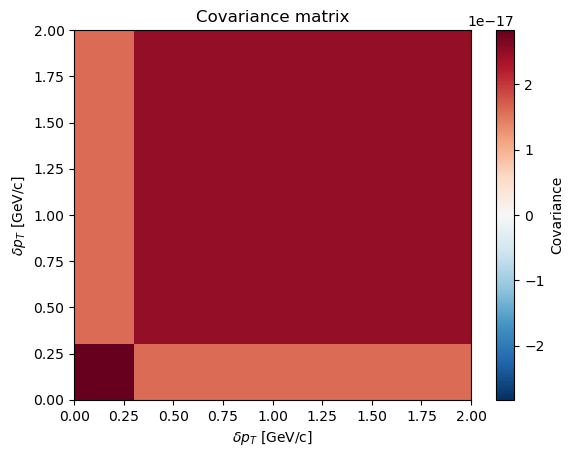

Covariance matrix for RecoDeltaPT : [[2.82528694e-17 1.59292467e-17]
 [1.59292467e-17 2.49196951e-17]]
('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])
binning_def[0] bin counts: [23.06136275 45.46356476]


<Figure size 640x480 with 0 Axes>

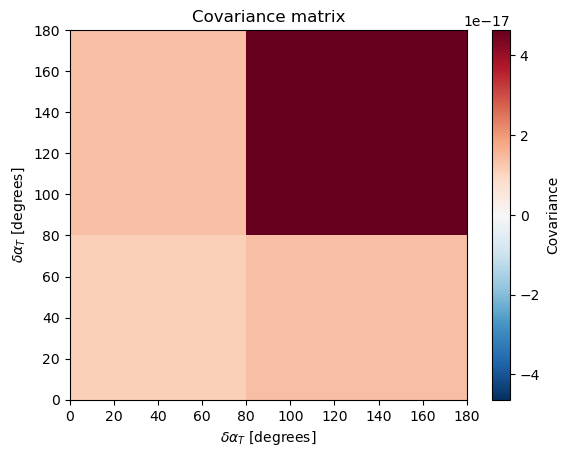

Covariance matrix for RecoDeltaAlphaT : [[1.10121308e-17 1.38406223e-17]
 [1.38406223e-17 4.63376824e-17]]


<Figure size 640x480 with 0 Axes>

In [8]:
selection = "OnePL_new"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    total_prediction = signal_generator.get_total_prediction(include_multisim_errors=True)
    print(f"binning_def[0] bin counts:", total_prediction.bin_counts)

    flux_norm_total_prediction = total_prediction / IntegratedFlux
    fig, ax = plt.subplots()
    flux_norm_total_prediction.draw_covariance_matrix(ax=ax, as_correlation=False)
    label = binning_def[0].lstrip("Reco")
    #plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{run_combo}_{label}_2bins.pdf', bbox_inches='tight')
    #plt.savefig(f'analysis_plots/unfolding_inputs/covariance_matrix_{run_combo}_{label}_2bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()
    
    #cov = total_prediction.covariance_matrix / IntegratedFlux**2
    cov = flux_norm_total_prediction.covariance_matrix
    print('Covariance matrix for', binning_def[0], ':', cov)
    
    # writing these to a file
    cov_str = "{"
    for i in range(cov.shape[0]):
        for j in range(cov.shape[1]):
            #print(cov[i][j])
            cov_str += f"{cov[i][j]},"
    cov_str = cov_str[:-1] # to remove the last comma
    cov_str += "};"
    # print(cov_str)
    with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
        f.writelines([f"{label}", " = ", f"{cov_str} \n"])
    

### Calculating the response matrix

In [9]:
from microfit import selections as sel
query = f"{sel.preselection_categories[preselection]['query']} and {sel.selection_categories[selection]['query']}"
#print(query)

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
sel_sig = all_mc.query(query, engine='python')

print(len(sel_sig))

variables = {
# #    '': {'reco': , 'truth': , 'nbins': , 'bounds': },
#     'Proton Kinetic Energy [GeV]': {'reco': 'trk_energy', 'truth': 'TrueLeadProtonKE', 'nbins': 10, 'bounds': (0, 1), 'range': [[0,1.3],[0,1.3]]},
#     'Proton Momentum [GeV/c]': {'reco': 'mod_trk_p', 'truth': 'TrueLeadProtonModMom', 'nbins': 20, 'bounds': (0, 1.5), 'range': [[0.1,2],[0.1,2]]},
#     'Proton X Momentum [GeV/c]': {'reco': 'trk_px', 'truth': 'TrueLeadProtonMomX', 'nbins': 20, 'bounds': (-1, 1), 'range': [[-1,1.25],[-1,1.25]]},
#     'Proton Y Momentum [GeV/c]': {'reco': 'trk_py', 'truth': 'TrueLeadProtonMomY', 'nbins': 20, 'bounds': (-1.5, 1.5), 'range': [[-1,1.5],[-1,1.5]]},
#     'Proton Z Momentum [GeV/c]': {'reco': 'trk_pz', 'truth': 'TrueLeadProtonMomZ', 'nbins': 20, 'bounds': (-1, 1.5),'range': [[-1,2],[-1,2]]},
#     'Electron Kinetic Energy [GeV]': {'reco': 'shr_energy_cali', 'truth': 'TrueElecKE', 'nbins': 16, 'bounds': (0, 4), 'range': [[0,4.6],[0,4.6]]},
#     'Electron Momentum [GeV/c]': {'reco': 'mod_shr_p', 'truth': 'TrueElecModMom', 'nbins': 20, 'bounds': (0, 5), 'range': [[0,4.6],[0,4.6]]},
#     'Electron X Momentum [GeV/c]': {'reco': 'shr_px', 'truth': 'TrueElecMomX', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
#     'Electron Y Momentum [GeV/c]': {'reco': 'shr_py', 'truth': 'TrueElecMomY', 'nbins': 12, 'bounds': (-1.5, 1.5), 'range': [[-1,1],[-1,1]]},
#     'Electron Z Momentum [GeV/c]': {'reco': 'shr_pz', 'truth': 'TrueElecMomZ', 'nbins': 12, 'bounds': (-1, 5), 'range': [[0,4.6],[0,4.6]]},
    '$\\delta p_T$ [GeV/c]': {'reco': 'RecoDeltaPT', 'truth': 'TrueDeltaPT', 'nbins': 20, 'bounds': (0, 2), 'range': [[0,1.75],[0,1.75]], 'bin_edges': [[0,0.3,1.75],[0,0.3,1.75]], 'bin_edges_1d': [0,0.3,1.75]},
    '$\\delta \\alpha_T$ [degrees]': {'reco': 'RecoDeltaAlphaT', 'truth': 'TrueDeltaAlphaT', 'nbins': 20, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,80,180],[0,80,180]], 'bin_edges_1d': [0,80,180]},
    '$p_n$ [GeV/c]': {'reco': 'RecoPN', 'truth': 'TruePN', 'nbins': 10, 'bounds': (0, 2), 'range': [[0,2.5],[0,2.5]], 'bin_edges': [[0,0.3,2.5],[0,0.3,2.5]], 'bin_edges_1d': [0,0.3,2.5]},
    '$\\alpha_{3D}$ [degrees]': {'reco': 'RecoAlpha3D', 'truth': 'TrueAlpha3D', 'nbins': 10, 'bounds': (0, 180), 'range': [[0,180],[0,180]], 'bin_edges': [[0,90,180],[0,90,180]], 'bin_edges_1d': [0,90,180]},
}

6020


In [12]:
with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
    f.write("\nResponse Matrices:\n")

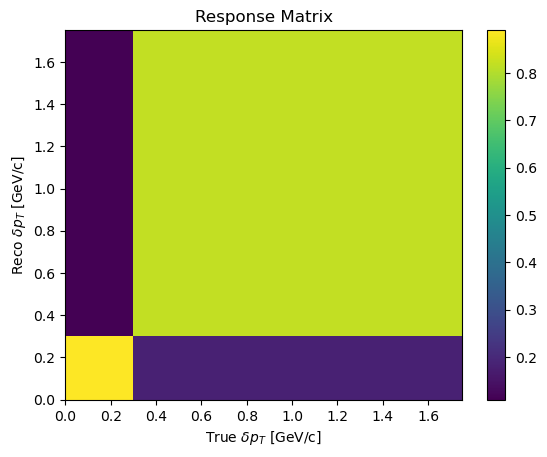

Response matrix for $\delta p_T$ [GeV/c] : [[0.89015333 0.18190072]
 [0.10984667 0.81766097]]
DeltaPT


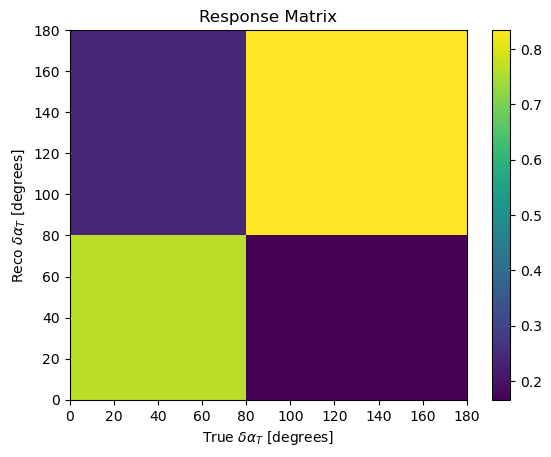

Response matrix for $\delta \alpha_T$ [degrees] : [[0.76476923 0.16585561]
 [0.23523077 0.83414439]]
DeltaAlphaT


<Figure size 640x480 with 0 Axes>

In [11]:
for k, var in variables.items():
    #print(type(k))
    truth = variables[k]['truth']
    reco = variables[k]['reco']
    bounds = variables[k]['range']
    bin_edges = variables[k]['bin_edges']
    bin_edges_1d = variables[k]['bin_edges_1d']
    
    truth_hist, truth_edges = np.histogram(sel_sig[truth], bins=bin_edges_1d, weights=sel_sig["weights"], range=bounds)
    H, xedges, yedges = np.histogram2d(sel_sig[truth], sel_sig[reco], bins=bin_edges, weights=sel_sig["weights"], range=bounds)
    
    resp = H.T / truth_hist
    
    X, Y = np.meshgrid(xedges,yedges)
    plt.pcolormesh(X, Y, resp, shading='flat') #, norm=LogNorm())
    plt.colorbar()
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Reco {k}')
    
    plt.title(f"Response Matrix")
    label = reco.lstrip("Reco")
    #plt.savefig(f'analysis_plots/unfolding_inputs/response_matrix_{run_combo}_{label}_2bins.pdf', bbox_inches='tight')
    #plt.savefig(f'analysis_plots/unfolding_inputs/response_matrix_{run_combo}_{label}_2bins.png', bbox_inches='tight')
    plt.show()
    plt.clf()
    
    print('Response matrix for', k, ':', resp)
    
    # writing these to a file
    resp_str = "{"
    for i in range(resp.shape[0]):
        for j in range(resp.shape[1]):
            #print(resp[i][j])
            resp_str += f"{resp[i][j]},"
    resp_str = resp_str[:-1] # to remove the last comma
    resp_str += "};"
    # print(cov_str)
    print(label)
    with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
        f.writelines([f"{label}", " = ", f"{resp_str} \n"])
    
#f.close()

### Extracting the uB tune MC signal prediction

In [19]:
with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
    f.write("\nuB Tune Signal Bin Counts:\n")

('RecoDeltaPT', None, None, '$\\delta p_T$ [GeV/c]', False, None, [0, 0.3, 2])
RecoDeltaPT bin counts: [13.64744529  5.12605524]
{13.647445290621985,5.126055244635857};
DeltaPT
('RecoDeltaAlphaT', None, None, '$\\delta \\alpha_T$ [degrees]', False, None, [0, 80, 180])
RecoDeltaAlphaT bin counts: [ 7.38500959 11.38849094]
{7.385009593542451,11.388490941715359};
DeltaAlphaT


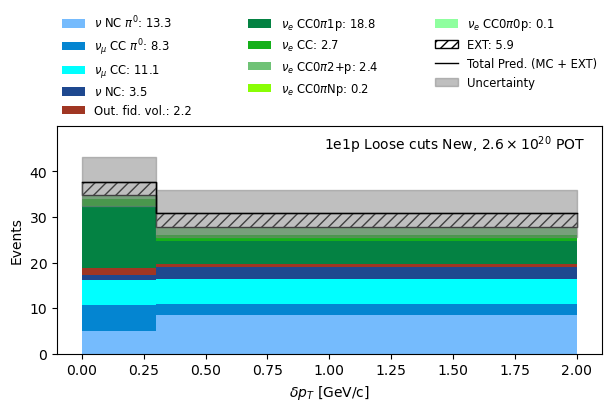

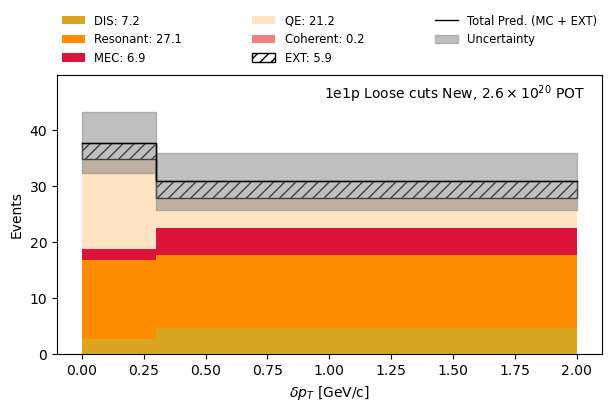

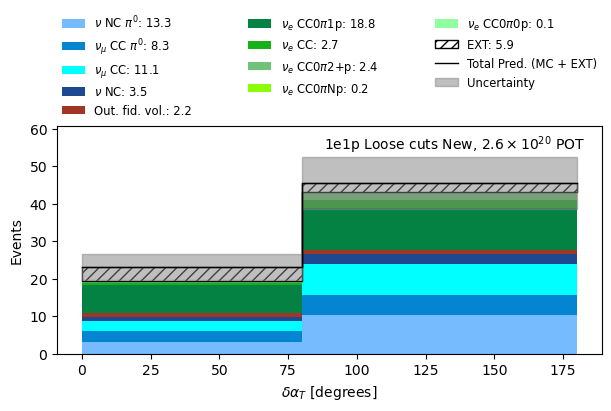

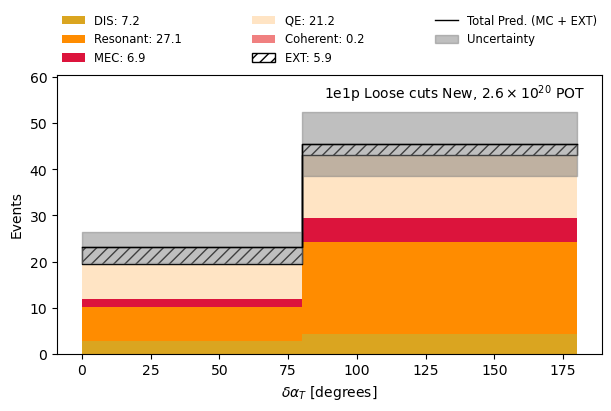

In [22]:
selection = "OnePL_new"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    plotter = rp.RunHistPlotter(signal_generator)
    axes = plotter.plot(
        category_column="category_1e1p",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )
    
    #plt.savefig(f'analysis_plots/unfolding_inputs/topo_{preselection}_{selection}_{binning_def[0]}_{run_combo}.pdf', bbox_inches='tight')
    #plt.savefig(f'analysis_plots/unfolding_inputs/topo_{preselection}_{selection}_{binning_def[0]}_{run_combo}.png', bbox_inches='tight')
    #plt.show()

    axes2 = plotter.plot(
        category_column="interaction",
        include_multisim_errors=True,
        add_ext_error_floor=False,
        show_data_mc_ratio=False,
        show_chi_square=False,
    )

    #plt.savefig(f'analysis_plots/unfolding_inputs/int_{preselection}_{selection}_{binning_def[0]}_{run_combo}.pdf', bbox_inches='tight')
    #plt.savefig(f'analysis_plots/unfolding_inputs/int_{preselection}_{selection}_{binning_def[0]}_{run_combo}.png', bbox_inches='tight')
    #plt.show()
    
    mc_hists = signal_generator.get_mc_hists(
        category_column="category_1e1p",
        include_multisim_errors=True,
    )
    
    mc_sig = mc_hists[12].bin_counts
    print(binning_def[0], 'bin counts:', mc_sig)
    
    label = binning_def[0].lstrip("Reco")
    
    # writing these to a file
    counts_str = "{"
    for i in mc_sig:
        counts_str += f"{i},"
    counts_str = counts_str[:-1] # to remove the last comma
    counts_str += "};"
    print(counts_str)
    print(label)
#     with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
#         f.writelines([f"{label}", " = ", f"{counts_str} \n"])
        
    
#f.close()

In [ ]:
with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
    f.write("\nBackground-subtracted Data Bin Counts:\n")

In [ ]:
selection = "OnePL_new"
preselection = "OneP_new"

for binning_def in vdef.TKI_variables_1e1p:
    # some binning definitions have more than 4 elements,
    # we ignore the last ones for now
    #binning = hist.Binning.from_config(*binning_def[:4])
    binning = hist.Binning.from_config(*binning_def)  # for variable bin sizes
    print(binning_def)
    signal_generator = hist.RunHistGenerator(
        rundata,
        binning,
        data_pot=data_pot,
        selection=selection,
        preselection=preselection,
        sideband_generator=None,
        uncertainty_defaults=None,
    )
    
    mc_hists = signal_generator.get_mc_hists(
        category_column="category_1e1p",
        include_multisim_errors=True,
    )
    
    label = binning_def[0].lstrip("Reco")
    
    if blinded == False:
        data_hist = signal_generator.get_data_hist()
        data_counts = data_hist.bin_counts
        bkg_mc_counts = {k: v.bin_counts for k, v in mc_hists.items() if k != 12}
        bkg_mc_sum = [sum(items) for items in zip(*bkg_mc_counts.values())]
        measure = [a - b for a, b in zip(data_counts, bkg_mc_sum)]
        print(binning_def[0], 'bkg-subtracted data counts:', measure)
        # writing these to a file
        measure_str = "{"
        for i in measure:
            measure_str += f"{i},"
        measure_str = measure_str[:-1] # to remove the last comma
        measure_str += "};"
        print(measure_str)
        print(label)
        with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
            f.writelines([f"{label}", " = ", f"{measure_str} \n"])

In [9]:
data_counts = [50,60]
mc_hists = {1: [10,20],
            2: [5,6],
            12: [7,8],
            20: [11, 15]}

bkg_hists = {k: v for k, v in mc_hists.items() if k != 12}
print(bkg_hists)
bkg_sum = [sum(items) for items in zip(*bkg_hists.values())]
print(bkg_sum)
measure = [a - b for a, b in zip(data_counts, bkg_sum)]
print(measure)

{1: [10, 20], 2: [5, 6], 20: [11, 15]}
[26, 41]
[24, 19]


In [28]:
# Calculating the metrics

print("Calculating metrics:")
print()

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])

all_sig = all_mc['category_1e1p'] == 12
tot_all_sig = np.sum(all_mc.loc[all_sig, 'weights'])
print('Total candidate signal events:', tot_all_sig)

all_predict = all_mc.query(query, engine='python')

is_sig = all_predict['category_1e1p'] == 12
tot_sig = np.sum(all_predict.loc[is_sig, 'weights'])
tot_bkg = np.sum(all_predict.loc[~is_sig, 'weights'])
tot_evt = np.sum(all_predict['weights'])
print('After cuts:')
print('Total signal events:', tot_sig)
print('Total background events:', tot_bkg)
print('Total events:', tot_evt)
print('sig + bkg =', tot_sig+tot_bkg)
print()

efficiency = (tot_sig / tot_all_sig) * 100
purity = (tot_sig / tot_evt) * 100
print('Efficiency:', efficiency)
print('Purity:', purity)
print()

pred_res = all_predict['interaction'] == 1
tot_res = np.sum(all_predict.loc[pred_res, 'weights'])
print('Total resonance events:', tot_res)
pred_qe = all_predict['interaction'] == 0
tot_qe = np.sum(all_predict.loc[pred_qe, 'weights'])
print('Total quasielastic events:', tot_qe)

print('QE/RES =', tot_qe/tot_res)
print('RES/QE =', tot_res/tot_qe)
print('QE/Total =', tot_qe/tot_evt)

with open(f'unfolding_inputs_{run_combo}.txt', 'a') as f:
    f.write("\nMetrics:\n")
    f.writelines(['\nTotal candidate signal events = ', f"{tot_all_sig} \n"])
    f.writelines(["After cuts: \n"])
    f.writelines(['Total signal events = ', f"{tot_sig} \n"])
    f.writelines(['Total background events = ', f"{tot_bkg} \n"])
    f.writelines(['Total events = ', f"{tot_evt} \n"])
    f.writelines(['\nPurity = ', f"{purity} % \n"])
    f.writelines(['Efficiency = ', f"{efficiency} % \n"])
    f.writelines(['\nQE/RES = ', f"{tot_qe/tot_res} \n"])
    f.writelines(['RES/QE = ', f"{tot_res/tot_qe} \n"])
    f.writelines(['QE/Total = ', f"{tot_qe/tot_evt} \n"])
    
f.close()

Calculating metrics:

Total candidate signal events: 75.91857918297016
After cuts:
Total signal events: 18.773500535257806
Total background events: 49.75142697223504
Total events: 68.52492750749286
sig + bkg = 68.52492750749285

Efficiency: 24.728466651110647
Purity: 27.396600358614048

Total resonance events: 27.130639162956335
Total quasielastic events: 21.167911550680426
QE/RES = 0.780221631474967
RES/QE = 1.2816870997405618
QE/Total = 0.3089081932755904


### Cells to work stuff out

In [6]:
# changing data_loading.py to load the samples without nue preselection applied.
path = 'run3/nuepresel/'
new_path = path[:-1]
new_path = new_path.rstrip('nuepresel')
print(new_path)

run3/


In [30]:
print(type(cov))
print(cov)

cov_str = "{"

for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        print(cov[i][j])
        cov_str += f"{cov[i][j]},"

cov_str = cov_str[:-1] # to remove the last comma
cov_str += "}"
print(cov_str)

with open('unfolding_inputs.txt', 'a') as f:
    f.writelines([f"{binning_def[0]}", " = ", f"{cov_str} \n"])

<class 'numpy.ndarray'>
[[1.10121308e-17 1.38406223e-17]
 [1.38406223e-17 4.63376824e-17]]
1.1012130829595665e-17
1.3840622316702883e-17
1.3840622316702883e-17
4.633768238183999e-17
{1.1012130829595665e-17,1.3840622316702883e-17,1.3840622316702883e-17,4.633768238183999e-17}


In [4]:
# Cross checking the integrated flux calculation with Afro's code:

runs = [["1"],["2"],["3"],["1","2","3"]]

for RUN in runs:
    
    rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=False,
    load_lee=False,
    load_nue_tki=True,
    blinded=True,
    load_crt_vars=False,
    enable_cache=True,)
    
    IntegratedFlux = (HistoFlux_int * data_pot / POTPerSpill / Nominal_UB_XY_Surface)
    print(RUN[0], ":", IntegratedFlux)
    
# Run 1 : 123183021064.94205
# Run 2 : 192519571844.01123
# Run 3 : 189421555745.37198
# Run 123 : 505124148654.3252

#It matches!

Loading run 1
1 : 123183021064.94205
Loading run 2
2 : 192519571844.01123
Loading run 3
3 : 189421555745.37198
Loading run 1
Loading run 2
Loading run 3
1 : 505124148654.3252


H: [[2.21747771e+01 1.59636017e+00 6.61003861e-03]
 [1.77156980e-02 1.75898906e-01 3.30501931e-03]]
Response: [[3.93030434e-03 3.00266068e-04]
 [2.82942248e-04 2.98133739e-03]
 [1.17157721e-06 5.60172764e-05]]


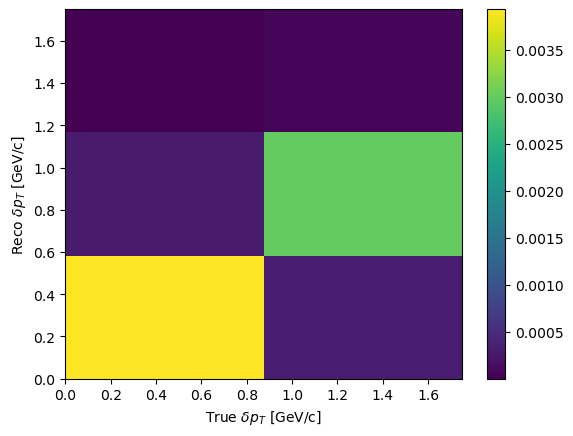

In [18]:
for k, var in variables.items():
    truth = variables[k]['truth']
    reco = variables[k]['reco']
    bounds = variables[k]['range']
    bin_edges = variables[k]['bin_edges']
    bin_edges_1d = variables[k]['bin_edges_1d']
    
    truth_hist, truth_edges = np.histogram(sel_sig[truth], bins=2, range = [0, 1.75])
    H, xedges, yedges = np.histogram2d(sel_sig[truth], sel_sig[reco], bins=[2,3], weights=sel_sig["weights"], range=bounds)
    print('H:', H)
    resp = H.T/truth_hist
    print('Response:', resp)
#     print(H.T[0])
#     print(truth_hist)

    X, Y = np.meshgrid(xedges,yedges)
    #plt.pcolormesh(X, Y, resp.T, shading='flat') #, norm=LogNorm())
    plt.pcolormesh(X, Y, resp, shading='flat') #, norm=LogNorm())
    plt.colorbar()
    plt.xlabel(f'True {k}')
    plt.ylabel(f'Reco {k}')